<a href="https://colab.research.google.com/github/kestrel677/Deep-Learning-Programs/blob/main/NLP(movie_review).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
import pandas as pd
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import ngrams
import re
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import string
import re
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Activation, Bidirectional
import tensorflow as tf
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns

In [16]:
df=pd.read_csv("/content/test.csv")
df.head(7)

,text,sentiment
0,"My daughter liked it but I was aghast, that a ...",neg
1,I... No words. No words can describe this. I w...,neg
2,this film is basically a poor take on the old ...,neg
3,"This is a terrible movie, and I'm not even sur...",neg
4,First of all this movie is a piece of reality ...,pos
5,"As a young lass, beautiful Joan Woodbury (as R...",neg
6,"Low budget, but still creepy enough to hold yo...",neg


In [17]:
print(df.isnull().sum())

text         0
sentiment    0
dtype: int64


In [18]:
df.shape

(25000, 2)

In [19]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

df['label'] = df['sentiment'].map({'neg': 1, 'pos': 0})

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def professional_clean(text):
    text = text.lower()
    text = re.sub(r'<br\s*/?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    words = text.split()
    cleaned_words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    return " ".join(cleaned_words)

df['clean_text'] = df['text'].apply(professional_clean)
df = df[df['clean_text'].str.strip() != ""]
df[['text', 'clean_text', 'label']].head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


,text,clean_text,label
0,"My daughter liked it but I was aghast, that a ...",daughter liked aghast character movie smoke is...,1
1,I... No words. No words can describe this. I w...,word word describe try sake brave people stick...,1
2,this film is basically a poor take on the old ...,film basically poor take old urban legend baby...,1
3,"This is a terrible movie, and I'm not even sur...",terrible movie im even sure terrible ugly one ...,1
4,First of all this movie is a piece of reality ...,first movie piece reality well realized artist...,0


In [20]:
for i in range (1,3):
    print("Reviews#"+str(i))
    Neg_Reviews= df[df['label'] == 1]['text'].iloc[i]
    print(Neg_Reviews+"\n")

Reviews#1
I... No words. No words can describe this. I will try for the sake of those few brave people who stick knives into their toasters... after watching this show.<br /><br />This... Cosgrove person... Her acting is like watching a female gorilla dance upon the nest of highly agitated insects. Perhaps I exaggerate. However, I have a feeling that the description fits a regular day of writing this show.<br /><br />The characters in this repulsive pile of raw sewage are as useless as a small piece of space rock that flies into the sun on any day of the week. Though heart attacks have not been experienced while watching them act like fools on the cheaply built sets, I have no doubt that it will happen eventually.<br /><br />The main plot of this *belches loudly into the faces of the actors* is that of a foolish girl who hosts a live weekly web-cast on the creatively titled iCarly.com with her brainless friends, one of which owns equipment that the producers of this show probably could

In [21]:
for i in range (1,3):
    print("Reviews#"+str(i))
    Pov_Reviews= df[df['label'] == 0]['text'].iloc[i]
    print(Pov_Reviews+"\n")

Reviews#1
If you want to see a film starring Stan laurel from the Laurel & Hardy comedies, this is not the film for you. Stan would not begin to find the character and rhythms of those films for another two years. If, however, you want a good travesty of the Rudolph Valentino BLOOD AND SAND, which had been made the previous year, this is the movie for you. All the stops are pulled out, both in physical comedy and on the title cards and if the movie is not held together by character, the plot of Valentino's movie is used -- well sort of.

Reviews#2
Cocky medical students play chicken with process that simulates death, in attempt to get a (hopefully temporary) view of the afterlife. Certain plot twists and themes are a little off the mark, and the acting occasionally goes over the top. But the underlying message - about God's and others' forgiveness for our real or perceived sins - is positive and unique in cinema, and the cast is very very good. The last sequence between Julia Roberts a

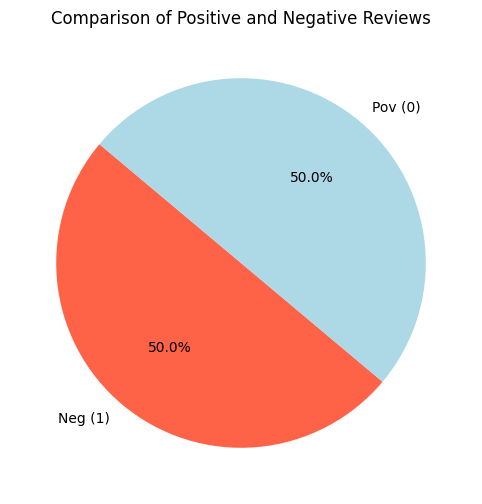

In [22]:
Review_counts = df['sentiment'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(Review_counts, labels=['Neg (1)', 'Pov (0)'], autopct='%1.1f%%', startangle=140, colors=['tomato', 'lightblue'])
plt.title('Comparison of Positive and Negative Reviews')
plt.show()

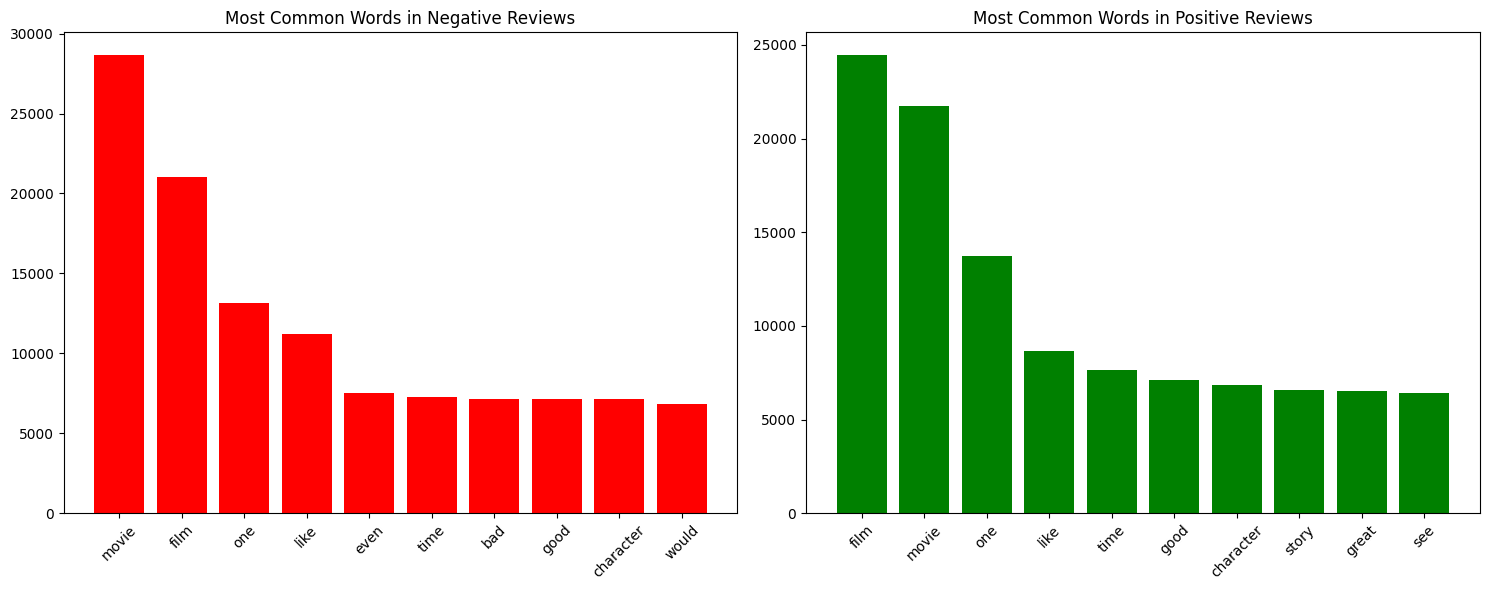

In [23]:
import matplotlib.pyplot as plt
from collections import Counter

neg_words = " ".join(df[df['label'] == 1]['clean_text']).split()
pos_words = " ".join(df[df['label'] == 0]['clean_text']).split()

neg_common = Counter(neg_words).most_common(10)
pos_common = Counter(pos_words).most_common(10)

neg_x, neg_y = zip(*neg_common) if neg_common else ([], [])
pos_x, pos_y = zip(*pos_common) if pos_common else ([], [])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(neg_x, neg_y, color='red')
axes[0].set_title('Most Common Words in Negative Reviews')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(pos_x, pos_y, color='green')
axes[1].set_title('Most Common Words in Positive Reviews')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

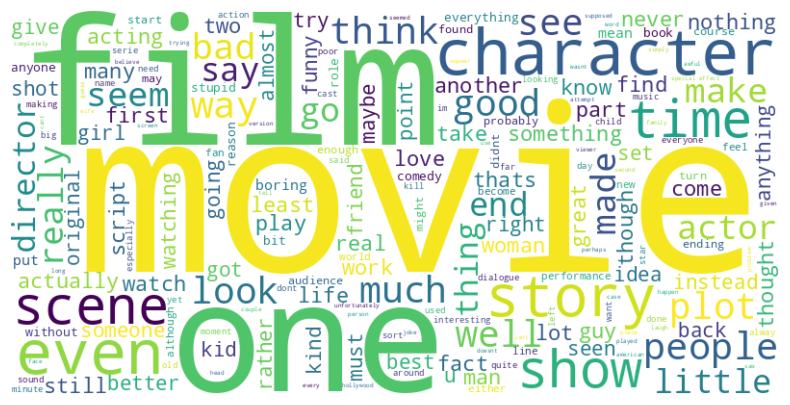

In [24]:
# Image of negative words
neg_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(neg_words))

plt.figure(figsize=(10, 5))
plt.imshow(neg_wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

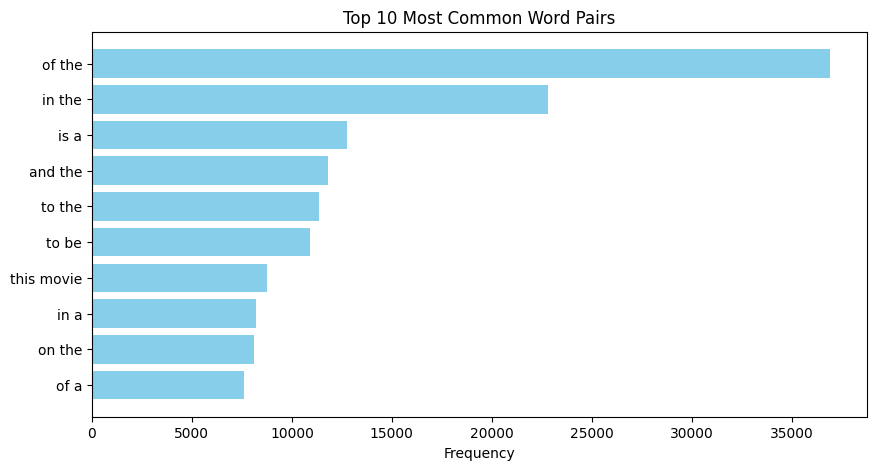

In [25]:
def generate_ngrams(text, n=2):
    words = text.split()
    if len(words) >= n:
        return [' '.join(grams) for grams in ngrams(words, n)]
    else:
        return []

df['Word Pairs'] = df['text'].apply(lambda x: generate_ngrams(x, n=2))

bigram_counts = Counter([bigram for sublist in df['Word Pairs'] for bigram in sublist])


most_common_bigrams = bigram_counts.most_common(10)

bigrams_df = pd.DataFrame(most_common_bigrams, columns=['Word Pairs', 'Frequency'])

plt.figure(figsize=(10, 5))
plt.barh(bigrams_df['Word Pairs'], bigrams_df['Frequency'], color='skyblue')
plt.xlabel('Frequency')
plt.title('Top 10 Most Common Word Pairs')
plt.gca().invert_yaxis()
plt.show()

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

X = df['clean_text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

vectorizer = TfidfVectorizer(max_features=5000)
X_train_vectorized = vectorizer.fit_transform(X_train)
X_test_vectorized = vectorizer.transform(X_test)

model = LogisticRegression()
model.fit(X_train_vectorized, y_train)

predictions = model.predict(X_test_vectorized)

print("Accuracy:", accuracy_score(y_test, predictions))
print(classification_report(y_test, predictions))

Accuracy: 0.8876
              precision    recall  f1-score   support

           0       0.87      0.91      0.89      2499
           1       0.90      0.87      0.89      2501

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



In [27]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

In [28]:
max_features = 5000
max_length = 500
embedding_vector_length = 32
model = tf.keras.Sequential()
model.add(Embedding(max_features, embedding_vector_length, input_length=max_length))
model.add(Bidirectional(tf.keras.layers.LSTM(64)))
model.add(Dense(16, activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [29]:
tokenizer = Tokenizer(num_words=max_features)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_padded = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

history = model.fit(X_train_padded, y_train_encoded,
                    batch_size=512,
                    epochs=3,
                    validation_data=(X_test_padded, y_test_encoded))

Epoch 1/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 95ms/step - accuracy: 0.6156 - loss: 0.6546 - val_accuracy: 0.6420 - val_loss: 0.6094
Epoch 2/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.7920 - loss: 0.4651 - val_accuracy: 0.8252 - val_loss: 0.3919
Epoch 3/3
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.8792 - loss: 0.3066 - val_accuracy: 0.8710 - val_loss: 0.3141


In [30]:
y_pred = model.predict(X_test_padded)
y_predict = [1 if o > 0.5 else 0 for o in y_pred]

157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step


In [31]:
cf_matrix =confusion_matrix(y_test_encoded,y_predict)
tn, fp, fn, tp = confusion_matrix(y_test_encoded,y_predict).ravel()
print("Precision: {:.2f}%".format(100 * precision_score(y_test_encoded, y_predict)))
print("Recall: {:.2f}%".format(100 * recall_score(y_test_encoded, y_predict)))
print("F1 Score: {:.2f}%".format(100 * f1_score(y_test_encoded,y_predict)))

Precision: 84.91%
Recall: 90.24%
F1 Score: 87.50%


[Text(0, 0.5, 'Positive'), Text(0, 1.5, 'Negative')]

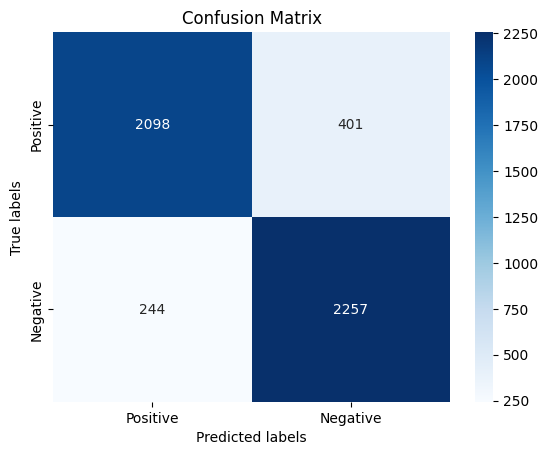

In [39]:
ax = plt.subplot()

sns.heatmap(cf_matrix, annot=True, ax=ax, cmap='Blues', fmt='')

ax.set_xlabel('Predicted labels')
ax.set_ylabel('True labels')
ax.set_title('Confusion Matrix')

# Since 0 is Positive and 1 is Negative
ax.xaxis.set_ticklabels(['Positive', 'Negative'])
ax.yaxis.set_ticklabels(['Positive', 'Negative'])

In [42]:
review_1 = ["This was an absolutely incredible experience! The storytelling was beautiful, the acting was flawless, and I was hooked from the very first minute."]

clean_review_1 = [professional_clean(review_1[0])]
sequence_1 = tokenizer.texts_to_sequences(clean_review_1)
padded_1 = pad_sequences(sequence_1, maxlen=max_length, padding='post')
prediction_1 = model.predict(padded_1)
label_1 = "Negative Review" if prediction_1[0][0] > 0.5 else "Positive Review"

print(f"Review: {review_1[0]}")
print(f"Raw Prediction Probability: {prediction_1[0][0]:.4f}")
print(f"Prediction: {label_1}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
Review: This was an absolutely incredible experience! The storytelling was beautiful, the acting was flawless, and I was hooked from the very first minute.
Raw Prediction Probability: 0.3818
Prediction: Positive Review



In [47]:
review_2 = ["I wasted two hours of my life on this garbage. The script was terrible and the characters were completely unlikable."]

clean_review_2 = [professional_clean(review_2[0])]
sequence_2 = tokenizer.texts_to_sequences(clean_review_2)
padded_2 = pad_sequences(sequence_2, maxlen=max_length, padding='post')
prediction_2 = model.predict(padded_2)
label_2 = "Negative Review" if prediction_2[0][0] > 0.5 else "Positive Review"

print(f"Review: {review_2[0]}")
print(f"Raw Prediction Probability: {prediction_2[0][0]:.4f}")
print(f"Prediction: {label_2}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Review: I wasted two hours of my life on this garbage. The script was terrible and the characters were completely unlikable.
Raw Prediction Probability: 0.9709
Prediction: Negative Review



In [46]:
review_3 = ["The cinematography was beautiful, but the pacing was so slow that I fell asleep halfway through."]

clean_review_3 = [professional_clean(review_3[0])]
sequence_3 = tokenizer.texts_to_sequences(clean_review_3)
padded_3 = pad_sequences(sequence_3, maxlen=max_length, padding='post')
prediction_3 = model.predict(padded_3)
label_3 = "Negative Review" if prediction_3[0][0] > 0.5 else "Positive Review"

print(f"Review: {review_3[0]}")
print(f"Raw Prediction Probability: {prediction_3[0][0]:.4f}")
print(f"Prediction: {label_3}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Review: The cinematography was beautiful, but the pacing was so slow that I fell asleep halfway through.
Raw Prediction Probability: 0.9070
Prediction: Negative Review



In [45]:
review_4 = ["This was a complete waste of time. The acting was terrible, the plot made absolutely no sense, and I wanted to leave after ten minutes."]

clean_review_4 = [professional_clean(review_4[0])]
sequence_4 = tokenizer.texts_to_sequences(clean_review_4)
padded_4 = pad_sequences(sequence_4, maxlen=max_length, padding='post')
prediction_4 = model.predict(padded_4)
label_4 = "Negative Review" if prediction_4[0][0] > 0.5 else "Positive Review"

print(f"Review: {review_4[0]}")
print(f"Raw Prediction Probability: {prediction_4[0][0]:.4f}")
print(f"Prediction: {label_4}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
Review: This was a complete waste of time. The acting was terrible, the plot made absolutely no sense, and I wanted to leave after ten minutes.
Raw Prediction Probability: 0.9744
Prediction: Negative Review



In [44]:
review_5 = ["A brilliantly crafted film with stunning performances and an incredibly heartwarming story that left me smiling."]

clean_review_5 = [professional_clean(review_5[0])]
sequence_5 = tokenizer.texts_to_sequences(clean_review_5)
padded_5 = pad_sequences(sequence_5, maxlen=max_length, padding='post')
prediction_5 = model.predict(padded_5)
label_5 = "Negative Review" if prediction_5[0][0] > 0.5 else "Positive Review"

print(f"Review: {review_5[0]}")
print(f"Raw Prediction Probability: {prediction_5[0][0]:.4f}")
print(f"Prediction: {label_5}\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Review: A brilliantly crafted film with stunning performances and an incredibly heartwarming story that left me smiling.
Raw Prediction Probability: 0.2528
Prediction: Positive Review



In [38]:
df.to_csv('cleaned_movie_reviews.csv', index=False)

from google.colab import files
files.download('cleaned_movie_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>